In [5]:
import pandas as pd
import numpy as np


In [6]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()

11

In [10]:
df[df['TotalCharges'].isna()][['customerID','tenure','MonthlyCharges','TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [11]:
df['TotalCharges']=df['TotalCharges'].fillna(0)
df.isnull().sum().sum()

0

In [12]:
print("Duplicate Rows",df.duplicated().sum())

Duplicate Rows 0


In [13]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [15]:
df.to_csv("telco_churn_cleaned.csv", index=False)
print("Cleaned data saved.")

Cleaned data saved.


In [16]:
import seaborn as sns 
import matplotlib.pyplot as plt

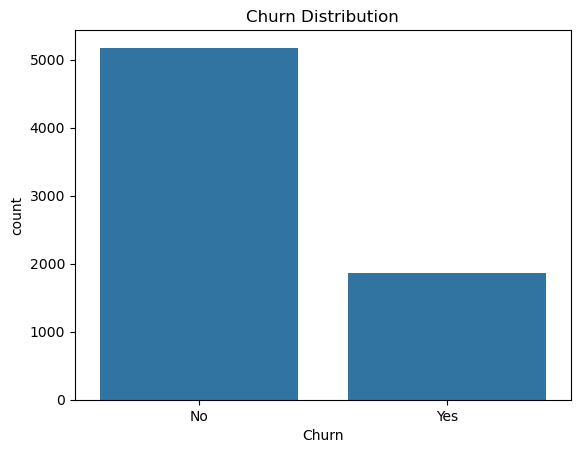

In [17]:
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()

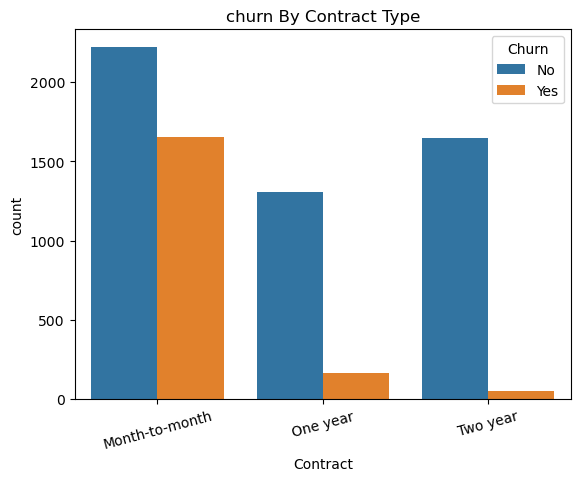

In [18]:
sns.countplot(data=df,x='Contract',hue='Churn')
plt.title('churn By Contract Type')
plt.xticks(rotation=15)
plt.show()

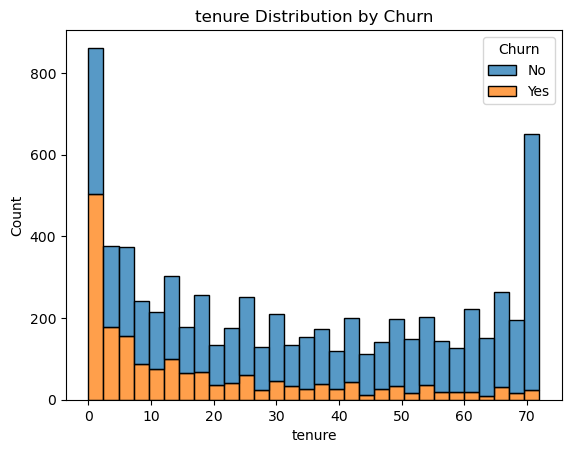

In [19]:
sns.histplot(data=df,x='tenure',hue='Churn',multiple='stack',bins=30)
plt.title('tenure Distribution by Churn')
plt.show()

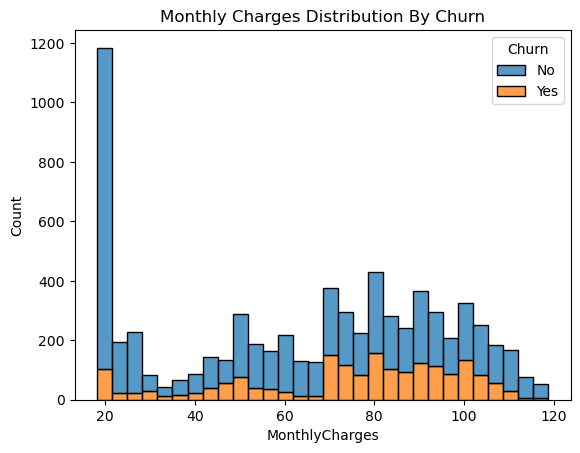

In [20]:
sns.histplot(data=df,x='MonthlyCharges',hue='Churn',multiple='stack',bins=30)
plt.title('Monthly Charges Distribution By Churn')
plt.show()

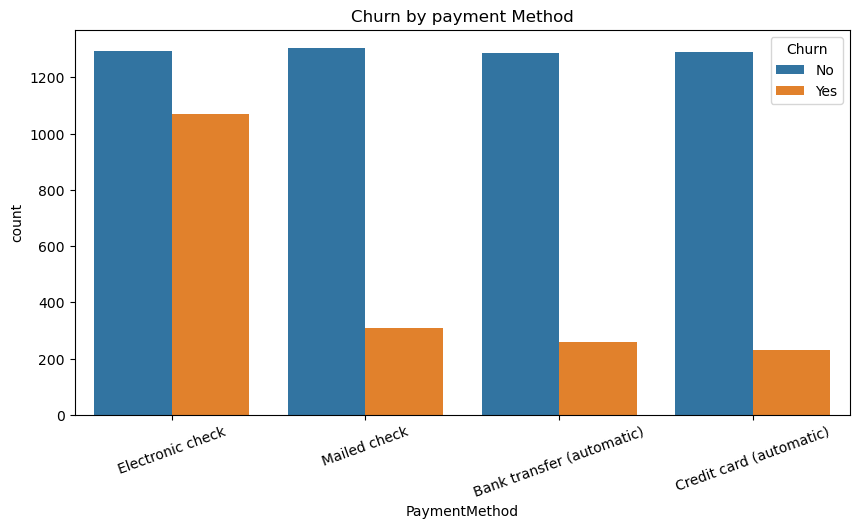

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='PaymentMethod',hue='Churn')
plt.title('Churn by payment Method')
plt.xticks(rotation=20)
plt.show()

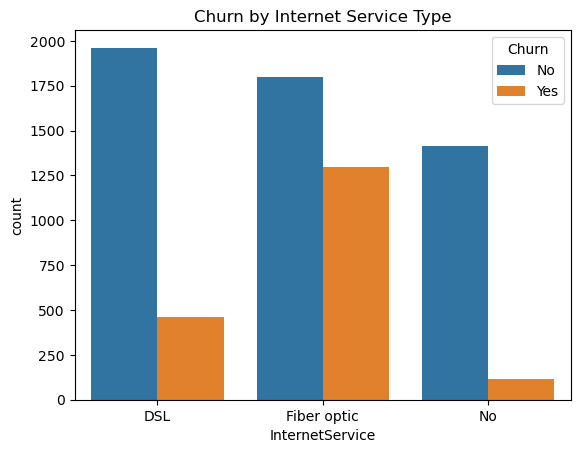

In [22]:
sns.countplot(data=df,x='InternetService',hue='Churn')
plt.title('Churn by Internet Service Type')
plt.show()

In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

0

In [24]:
#categorical columns encode

df_model=df.drop('customerID',axis=1)
df_model['Churn']=df_model['Churn'].map({'Yes':1,'No':0})
df_model=pd.get_dummies(df_model,drop_first=True)

df_model.shape
df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [25]:
# Model Train-Test Split

from sklearn.model_selection import train_test_split

x = df_model.drop('Churn', axis=1)
y = df_model['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train.shape, x_test.shape

((5634, 30), (1409, 30))

In [26]:
#Model Training i)LogisticRegression

from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

C:\Users\user5\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
model = LogisticRegression(max_iter=5000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [28]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.8225691980127751
[[934 102]
 [148 225]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7849538679914834
[[943  93]
 [210 163]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.44      0.52       373

    accuracy                           0.78      1409
   macro avg       0.73      0.67      0.69      1409
weighted avg       0.77      0.78      0.77      1409



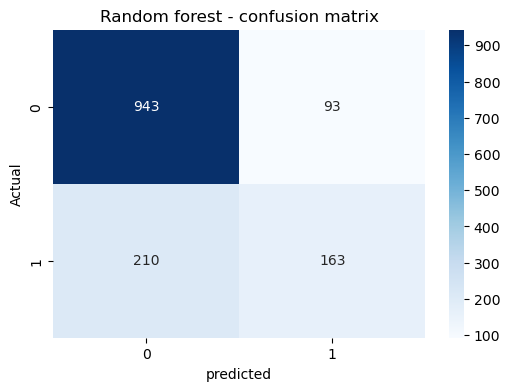

In [30]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Random forest - confusion matrix")
plt.show()

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

rf_model.fit(x_train,y_train)

y_pred_rf=rf_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7849538679914834
[[943  93]
 [210 163]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.44      0.52       373

    accuracy                           0.78      1409
   macro avg       0.73      0.67      0.69      1409
weighted avg       0.77      0.78      0.77      1409



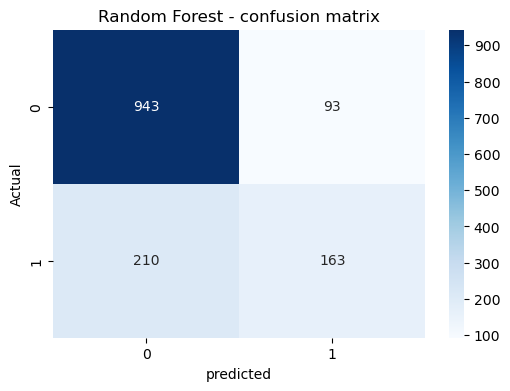

In [64]:
cm=confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Random Forest - confusion matrix")

plt.show()

In [70]:
feature_importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

                                  Feature  Importance
3                            TotalCharges    0.192677
2                          MonthlyCharges    0.172247
1                                  tenure    0.171681
10            InternetService_Fiber optic    0.037451
28         PaymentMethod_Electronic check    0.035764
25                      Contract_Two year    0.029908
13                     OnlineSecurity_Yes    0.029213
4                             gender_Male    0.026934
26                   PaperlessBilling_Yes    0.025771
19                        TechSupport_Yes    0.023863
5                             Partner_Yes    0.023585
24                      Contract_One year    0.022484
15                       OnlineBackup_Yes    0.022390
6                          Dependents_Yes    0.021024
9                       MultipleLines_Yes    0.020635
0                           SeniorCitizen    0.019894
17                   DeviceProtection_Yes    0.018980
23                    Stream

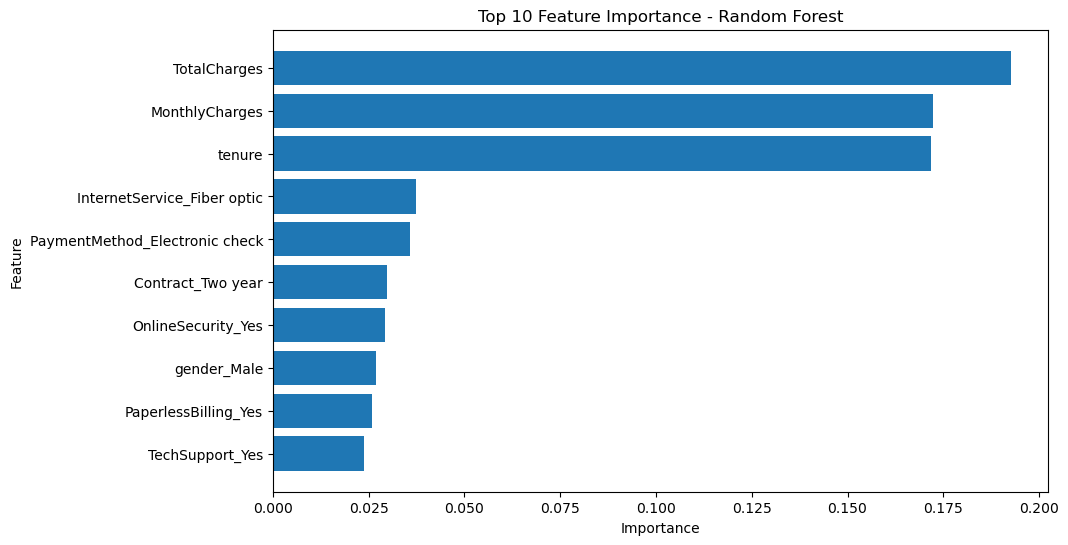

In [74]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'][:10],
    importance_df['Importance'][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.show()

In [78]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC Score:", roc_auc)

Random Forest ROC-AUC Score: 0.8368337698096411


In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(x_train, y_train)

y_pred_lr = lr_model.predict(x_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8218594748048261


C:\Users\user5\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [82]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

Confusion Matrix:
[[934 102]
 [149 224]]


In [84]:
y_prob_lr = lr_model.predict_proba(x_test)[:, 1]

lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC Score:", lr_roc_auc)

Logistic Regression ROC-AUC Score: 0.8624983179272723


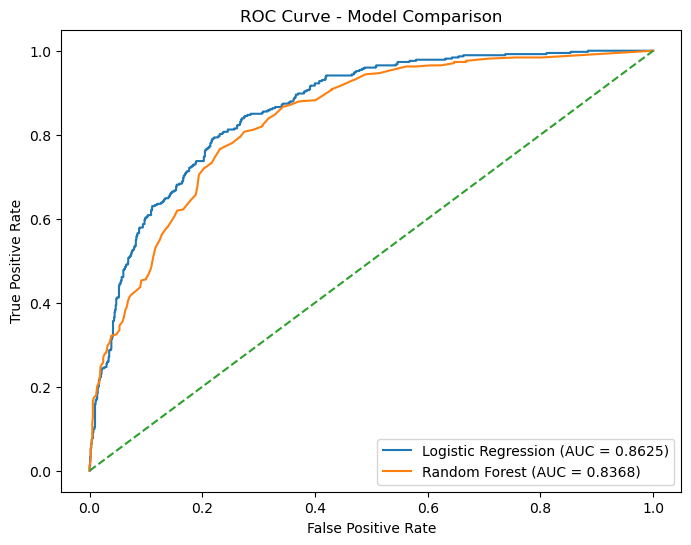

In [86]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = 0.8625)')
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = 0.8368)')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")

plt.legend()
plt.show()

In [88]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, 0.7849538679914834],
    'ROC-AUC': [lr_roc_auc, 0.8368337698096411]
})

comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.821859,0.862498
1,Random Forest,0.784954,0.836834


In [90]:
print("Final Model: Logistic Regression")
print("Accuracy:", lr_accuracy)
print("ROC-AUC:", lr_roc_auc)

Final Model: Logistic Regression
Accuracy: 0.8218594748048261
ROC-AUC: 0.8624983179272723


## Conclusion

In this project, Customer Churn Prediction was performed using Machine Learning classification algorithms.

Two models, Logistic Regression and Random Forest, were trained and evaluated.

Logistic Regression achieved an accuracy of 82.19% and a ROC-AUC score of 0.8625, while Random Forest achieved an accuracy of 78.50% and a ROC-AUC score of 0.8368.

Based on the evaluation results, Logistic Regression performed better than Random Forest. Therefore, Logistic Regression was selected as the final model for customer churn prediction.

The model can help businesses identify customers who are likely to churn and take appropriate retention actions.